# NB-00 — Environment Setup & Foundations

**Goal:** Verify your environment is ready. Understand what libraries we use and why. Load your first vision model.

**What you'll do:**
1. Detect GPU/CPU device
2. Validate HuggingFace token
3. Load a tiny ViT model and run inference
4. Understand tensor shapes for images
5. Build intuition for the full pipeline we'll build

---

## 1. Library Versions
Always record library versions — crucial for reproducibility.

In [1]:
import sys
import torch
import transformers
import PIL
import numpy as np

print(f"Python:         {sys.version.split()[0]}")
print(f"PyTorch:        {torch.__version__}")
print(f"Transformers:   {transformers.__version__}")
print(f"Pillow:         {PIL.__version__}")
print(f"NumPy:          {np.__version__}")

# Optional: check other key libraries
try:
    import peft; print(f"PEFT:           {peft.__version__}")
except ImportError:
    print("PEFT:           NOT INSTALLED — run: pip install peft")

try:
    import accelerate; print(f"Accelerate:     {accelerate.__version__}")
except ImportError:
    print("Accelerate:     NOT INSTALLED — run: pip install accelerate")

Python:         3.13.9
PyTorch:        2.12.0
Transformers:   5.8.1
Pillow:         12.2.0
NumPy:          2.4.5
PEFT:           0.19.1
Accelerate:     1.13.0


## 2. Device Detection

Our pipeline needs to run on whatever hardware you have:
- **CUDA** (NVIDIA GPU) — fastest, required for large models
- **MPS** (Apple Silicon) — good for development on Mac
- **CPU** — slowest, but always available; fine for small experiments

In [2]:
import torch

def get_device() -> torch.device:
    """Auto-detect the best available device."""
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"✅ CUDA available: {torch.cuda.get_device_name(0)}")
        print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Apple MPS available (Apple Silicon)")
    else:
        device = torch.device("cpu")
        print("⚠️  No GPU found — using CPU. Large models will be slow.")
    return device

DEVICE = get_device()
print(f"\nUsing device: {DEVICE}")

✅ Apple MPS available (Apple Silicon)

Using device: mps


## 3. HuggingFace Token Setup

We download models from HuggingFace Hub. You need a free account and token.

**Get your token:** https://huggingface.co/settings/tokens

We store it in `.env` — never hardcode tokens in notebooks!

In [3]:
import os
from pathlib import Path

# Load from .env file if it exists (project root)
env_file = Path(".env")
if not env_file.exists():
    env_file = Path("../.env")  # fallback when cwd is notebooks/
if env_file.exists():
    from dotenv import load_dotenv
    load_dotenv(env_file)
    print("✅ .env file loaded")
else:
    print("⚠️  No .env file found — copy .env.example to .env and fill in your token")

HF_TOKEN = os.getenv("HF_TOKEN")

if HF_TOKEN and HF_TOKEN != "your_token_here":
    # Mask token for display
    masked = HF_TOKEN[:4] + "..." + HF_TOKEN[-4:]
    print(f"✅ HF_TOKEN found: {masked}")
    
    # Login to HuggingFace
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)
    print("✅ Logged in to HuggingFace Hub")
else:
    print("⚠️  HF_TOKEN not set. Public models will still work.")
    print("   Set HF_TOKEN in your .env file for gated models (Llama, Qwen etc.)")

✅ .env file loaded
✅ HF_TOKEN found: hf_e...RPeU


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✅ Logged in to HuggingFace Hub


## 4. Image Tensor Shapes — The Foundation

Before loading any model, understand the data format.

A color image is a 3D array: `[channels, height, width]`
- Channels: 3 (Red, Green, Blue)
- Height: pixel rows
- Width: pixel columns

A batch of images: `[batch_size, channels, height, width]`

Vision models like ViT expect images normalized to a specific mean/std.

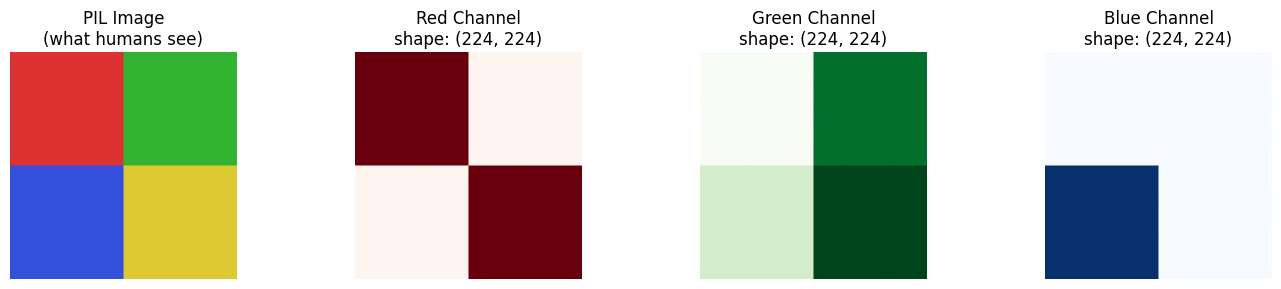

PIL Image size (W x H): (224, 224)
NumPy array shape (H, W, C): (224, 224, 3)

PyTorch uses (C, H, W) — note the channel-first convention:
Tensor shape: torch.Size([3, 224, 224])  → [C=3, H=224, W=224]
Batch shape:  torch.Size([1, 3, 224, 224])  → [B=1, C=3, H=224, W=224]


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch

# --- Synthesize a colorful test image ---
# In real code, we'd load from disk: Image.open("path.jpg")
img_array = np.zeros((224, 224, 3), dtype=np.uint8)
# Red quadrant
img_array[:112, :112] = [220, 50, 50]
# Green quadrant
img_array[:112, 112:] = [50, 180, 50]
# Blue quadrant
img_array[112:, :112] = [50, 80, 220]
# Yellow quadrant
img_array[112:, 112:] = [220, 200, 50]

pil_image = Image.fromarray(img_array)

fig, axes = plt.subplots(1, 4, figsize=(14, 3))

axes[0].imshow(pil_image)
axes[0].set_title("PIL Image\n(what humans see)")
axes[0].axis('off')

# Show each channel separately
channel_names = ['Red Channel', 'Green Channel', 'Blue Channel']
colors = ['Reds', 'Greens', 'Blues']
img_np = np.array(pil_image)
for i, (name, cmap) in enumerate(zip(channel_names, colors)):
    axes[i+1].imshow(img_np[:, :, i], cmap=cmap)
    axes[i+1].set_title(f"{name}\nshape: {img_np[:,:,i].shape}")
    axes[i+1].axis('off')

plt.tight_layout()
plt.show()

print(f"PIL Image size (W x H): {pil_image.size}")
print(f"NumPy array shape (H, W, C): {img_np.shape}")
print(f"\nPyTorch uses (C, H, W) — note the channel-first convention:")

# Convert to PyTorch tensor: HWC → CHW, normalize to [0,1]
tensor = torch.from_numpy(img_np).permute(2, 0, 1).float() / 255.0
print(f"Tensor shape: {tensor.shape}  → [C=3, H=224, W=224]")

# Add batch dimension
batch = tensor.unsqueeze(0)
print(f"Batch shape:  {batch.shape}  → [B=1, C=3, H=224, W=224]")

## 5. Load Your First Vision Model (ViT)

We use `google/vit-base-patch16-224` — a small ViT model.

**Key question to keep in mind:** What shape does the output have? Why?

- Image: 224×224 pixels
- Patch size: 16×16 pixels  
- Number of patches: (224/16)² = 196
- Plus 1 `[CLS]` token = **197 total tokens**
- Each token is a 768-dim vector (for "base" model)

So output is: `[batch, 197, 768]`

In [5]:
from transformers import ViTModel, ViTImageProcessor
import torch
from PIL import Image

print("Loading ViT model... (downloads ~330MB on first run)")

MODEL_ID = "google/vit-base-patch16-224"

# Image processor: handles resizing and normalization
feature_extractor = ViTImageProcessor.from_pretrained(MODEL_ID)

# The model itself
model = ViTModel.from_pretrained(MODEL_ID)
model.eval()  # inference mode
model = model.to(DEVICE)

print(f"\nModel loaded! Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")
print(f"Model on device: {next(model.parameters()).device}")

Loading ViT model... (downloads ~330MB on first run)


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Model loaded! Parameters: 86.4M
Model on device: mps:0


In [6]:
# --- Run inference and inspect output shapes ---

# Preprocess: feature extractor normalizes the image
inputs = feature_extractor(images=pil_image, return_tensors="pt")
pixel_values = inputs["pixel_values"].to(DEVICE)

print(f"Input pixel_values shape: {pixel_values.shape}")
print(f"  → [batch=1, channels=3, height=224, width=224]")

with torch.no_grad():
    outputs = model(pixel_values=pixel_values)

# last_hidden_state: all token embeddings
all_tokens = outputs.last_hidden_state
print(f"\nOutput (all tokens) shape: {all_tokens.shape}")
print(f"  → [batch=1, num_tokens=197, hidden_dim=768]")
print(f"  → 197 = 196 image patches + 1 [CLS] token")

# CLS token: first token, summarizes the whole image
cls_token = all_tokens[:, 0, :]
print(f"\nCLS token shape: {cls_token.shape}")
print(f"  → [batch=1, hidden_dim=768] — one vector per image")

# Patch tokens: remaining 196 tokens
patch_tokens = all_tokens[:, 1:, :]
print(f"Patch tokens shape: {patch_tokens.shape}")
print(f"  → [batch=1, num_patches=196, hidden_dim=768]")

Input pixel_values shape: torch.Size([1, 3, 224, 224])
  → [batch=1, channels=3, height=224, width=224]

Output (all tokens) shape: torch.Size([1, 197, 768])
  → [batch=1, num_tokens=197, hidden_dim=768]
  → 197 = 196 image patches + 1 [CLS] token

CLS token shape: torch.Size([1, 768])
  → [batch=1, hidden_dim=768] — one vector per image
Patch tokens shape: torch.Size([1, 196, 768])
  → [batch=1, num_patches=196, hidden_dim=768]


## 6. Visualize the Patch Grid

Let's see how ViT divides the image into 16×16 patches.

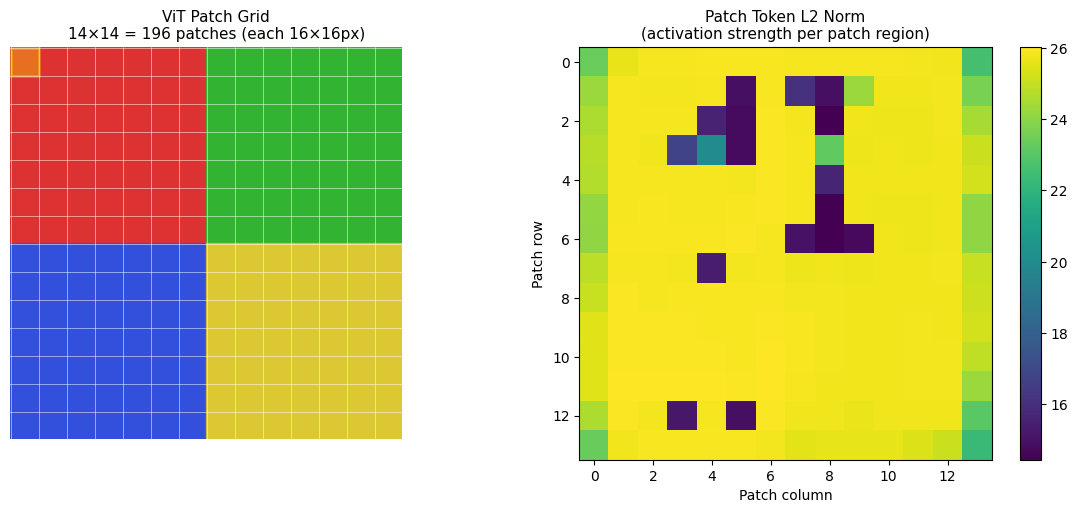

Each colored cell = one 16×16 patch
The heatmap shows how 'active' each patch's representation is
Brighter patches → higher activation → more distinctive region


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: original image with patch grid overlay
axes[0].imshow(pil_image)
patch_size = 16
img_size = 224
num_patches_per_side = img_size // patch_size  # 14

for i in range(num_patches_per_side + 1):
    axes[0].axhline(i * patch_size, color='white', linewidth=0.5, alpha=0.7)
    axes[0].axvline(i * patch_size, color='white', linewidth=0.5, alpha=0.7)

# Highlight patch #0 (top-left)
rect = mpatches.FancyBboxPatch((0, 0), patch_size, patch_size,
    boxstyle="square,pad=0", linewidth=2, edgecolor='yellow', facecolor='yellow', alpha=0.3)
axes[0].add_patch(rect)
axes[0].set_title(f"ViT Patch Grid\n{num_patches_per_side}×{num_patches_per_side} = {num_patches_per_side**2} patches (each {patch_size}×{patch_size}px)",
    fontsize=11)
axes[0].axis('off')

# Right: visualize the 196 patch tokens as a heatmap (L2 norm per patch)
patch_norms = patch_tokens[0].norm(dim=-1).cpu().numpy()  # [196]
patch_grid = patch_norms.reshape(num_patches_per_side, num_patches_per_side)  # [14, 14]

im = axes[1].imshow(patch_grid, cmap='viridis', interpolation='nearest')
plt.colorbar(im, ax=axes[1])
axes[1].set_title("Patch Token L2 Norm\n(activation strength per patch region)", fontsize=11)
axes[1].set_xlabel("Patch column")
axes[1].set_ylabel("Patch row")

plt.tight_layout()
plt.show()

print("Each colored cell = one 16×16 patch")
print("The heatmap shows how 'active' each patch's representation is")
print("Brighter patches → higher activation → more distinctive region")

## 7. Memory & Performance Baseline

In [8]:
import time

# Warm-up
with torch.no_grad():
    _ = model(pixel_values=pixel_values)

# Benchmark
N = 10
start = time.perf_counter()
with torch.no_grad():
    for _ in range(N):
        _ = model(pixel_values=pixel_values)
elapsed = time.perf_counter() - start

print("=" * 40)
print("Performance Baseline (ViT-Base)")
print("=" * 40)
print(f"Device:           {DEVICE}")
print(f"Latency per image: {elapsed/N*1000:.1f} ms")
print(f"Throughput:        {N/elapsed:.1f} images/sec")

if DEVICE.type == "cuda":
    mem_mb = torch.cuda.max_memory_allocated() / 1e6
    print(f"Peak GPU memory:   {mem_mb:.0f} MB")

print()
print("Note: ViT-Base is tiny compared to CLIP ViT-L/14 or LLaVA-7B.")
print("This baseline helps us understand overhead at scale.")

Performance Baseline (ViT-Base)
Device:           mps
Latency per image: 6.0 ms
Throughput:        168.0 images/sec

Note: ViT-Base is tiny compared to CLIP ViT-L/14 or LLaVA-7B.
This baseline helps us understand overhead at scale.


## 8. The Big Picture — What We're Building

Here's the full pipeline we'll assemble over the next 8 phases:

In [ ]:
pipeline_diagram = """
╔══════════════════════════════════════════════════════════════════╗
║           MULTIMODAL QA PIPELINE — What We're Building          ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  📷 Image Input          📝 Text Question                        ║
║       │                        │                                 ║
║       ▼                        ▼                                 ║
║  ┌─────────────┐        ┌──────────────┐                         ║
║  │ CLIP / ViT  │        │  Tokenizer   │  ← Phase 1 (you're here)║
║  │  Encoder    │        │              │                         ║
║  └──────┬──────┘        └──────┬───────┘                         ║
║         │ [B, 197, 1024]       │ [B, seq_len]                    ║
║         ▼                      │                                 ║
║  ┌─────────────┐               │                                 ║
║  │  Projector  │               │           ← Phase 2             ║
║  │ Linear/MLP/ │               │                                 ║
║  │  Q-Former   │               │                                 ║
║  └──────┬──────┘               │                                 ║
║         │ [B, 197, 4096]       │                                 ║
║         └─────────┬────────────┘                                 ║
║                   ▼                                              ║
║          ┌────────────────┐                                       ║
║          │  LLM Backbone  │                    ← Phase 3          ║
║          │  Qwen-VL / LLaVA│                                     ║
║          └────────┬───────┘                                       ║
║                   │                                              ║
║                   ▼                                              ║
║           💬 "The dog is sitting on a red sofa."                 ║
║                                                                  ║
║  ─────────────────────────────────────────────────────────────   ║
║  Phase 5: Fine-tune with LoRA for your specific domain           ║
║  Phase 6: Add RAG to ground answers in a knowledge base          ║
║  Phase 7: Serve via API + OpenWebUI chat interface               ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(pipeline_diagram)

## ✅ Phase 0 Checklist

Before moving to Phase 1, verify:

- [ ] All library versions printed without errors
- [ ] Device detected correctly (CUDA / MPS / CPU)
- [ ] HuggingFace token configured (or confirmed public-only access)
- [ ] ViT model loaded and output shape is `[1, 197, 768]`
- [ ] Patch grid visualization makes sense to you
- [ ] You can answer: **What is a patch? What is the CLS token?**

**Next:** Open `NB-01-vit-exploration.ipynb` to go deeper into ViT internals.

**Update PROGRESS.md** — check off Phase 0 items!